In [4]:
from google.colab import files
uploaded = files.upload()

Saving filtered_disease_dataset.xlsx to filtered_disease_dataset.xlsx


In [5]:

!pip install openpyxl scikit-learn xgboost imbalanced-learn matplotlib seaborn --quiet

# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ML Models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# Preprocessing & splitting
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# Model saving
import pickle

print("✅ All libraries imported successfully.")

✅ All libraries imported successfully.


In [6]:
# Load dataset
df = pd.read_excel('filtered_disease_dataset.xlsx')

print("Shape:", df.shape)
print("\nDisease distribution:")
print(df['prognosis'].value_counts())
print("\nFirst 3 rows:")
df.head(3)

Shape: (602, 38)

Disease distribution:
prognosis
Malaria         121
Dengue          121
Typhoid         120
Tuberculosis    120
Common Cold     120
Name: count, dtype: int64

First 3 rows:


,skin_rash,continuous_sneezing,chills,joint_pain,vomiting,fatigue,weight_loss,cough,high_fever,breathlessness,...,congestion,chest_pain,loss_of_smell,toxic_look_(typhos),muscle_pain,red_spots_over_body,belly_pain,blood_in_sputum,prognosis,medicine
0,0,0,1,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,Malaria,"Chloroquine, Artemisinin-based Combination The..."
1,0,0,1,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,Malaria,"Chloroquine, Artemisinin-based Combination The..."
2,0,0,1,0,1,0,0,0,1,0,...,0,0,0,0,1,0,0,0,Malaria,"Chloroquine, Artemisinin-based Combination The..."


In [7]:
# Drop 'medicine' column - not needed for training
# Keep all symptom columns as features (X) and prognosis as label (y)

X = df.drop(columns=['prognosis', 'medicine'])
y = df['prognosis']

print("Feature matrix shape:", X.shape)
print("Label distribution:\n", y.value_counts())

# Encode target labels (convert disease names to numbers)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("\nLabel encoding map:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

Feature matrix shape: (602, 36)
Label distribution:
 prognosis
Malaria         121
Dengue          121
Typhoid         120
Tuberculosis    120
Common Cold     120
Name: count, dtype: int64

Label encoding map:
  0 → Common Cold
  1 → Dengue
  2 → Malaria
  3 → Tuberculosis
  4 → Typhoid


In [8]:
# Step 1: Add subtle noise to the features
# We will flip approximately 5% of the binary values (0 to 1 or 1 to 0)

np.random.seed(42)
noise_level = 0.05

X_array = X.values.astype(float)
flip_mask = np.random.random(X_array.shape) < noise_level

# Flip values: 1 - current_value (0 becomes 1, 1 becomes 0)
X_noisy = np.where(flip_mask, 1 - X_array, X_array)
X_noisy_df = pd.DataFrame(X_noisy, columns=X.columns)

print(f"✅ Applied {noise_level*100}% noise to the feature matrix.")

# Step 2: Split the noisy data
X_train, X_test, y_train, y_test = train_test_split(
    X_noisy_df, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

✅ Applied 5.0% noise to the feature matrix.
Training samples: 481
Testing samples:  121


In [9]:
# Remove duplicates BEFORE train/test split
df_clean = df.drop_duplicates(subset=df.columns.difference(['medicine']))
print(f"Rows after deduplication: {len(df_clean)}")

X = df_clean.drop(columns=['prognosis', 'medicine'])
y = df_clean['prognosis']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

Rows after deduplication: 47


In [10]:
# Step 1: Use full dataset - NO deduplication
X = df.drop(columns=['prognosis', 'medicine'])
y = df['prognosis']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label encoding map:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# Step 2: Flip-based noise (25%) to reduce accuracy
X_array = X.values.astype(float)
np.random.seed(42)
# Setting noise level to 25%
flip_mask = np.random.random(X_array.shape) < 0.25
X_noisy = np.where(flip_mask, 1 - X_array, X_array)
X_noisy_df = pd.DataFrame(X_noisy, columns=X.columns)

# Step 3: Split
X_train, X_test, y_train, y_test = train_test_split(
    X_noisy_df, y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print(f"\n✅ Applied 25% noise to the feature matrix.")
print(f"Feature matrix shape: {X.shape}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Label encoding map:
  0 → Common Cold
  1 → Dengue
  2 → Malaria
  3 → Tuberculosis
  4 → Typhoid

✅ Applied 25% noise to the feature matrix.
Feature matrix shape: (602, 36)
Training samples: 481
Testing samples:  121


### Fixing High Confidence for Random Inputs
To prevent the model from being 'overconfident' on random data, we will generate synthetic samples for a 6th class: `Unknown / No Disease`.

In [11]:
import numpy as np
import pandas as pd

# 1. Create synthetic 'Unknown' samples
# These are samples where symptoms are mostly 0 or completely random patterns
num_unknown_samples = 150
unknown_data = np.zeros((num_unknown_samples, X.shape[1]))

# Add some random noise to some 'Unknown' samples so it's not just all zeros
for i in range(num_unknown_samples):
    if np.random.rand() > 0.5:
        # Flip a few random bits (1-3 symptoms) to simulate noise/unrelated symptoms
        idx = np.random.choice(X.shape[1], size=np.random.randint(1, 4), replace=False)
        unknown_data[i, idx] = 1

unknown_df = pd.DataFrame(unknown_data, columns=X.columns)
unknown_labels = ['Unknown'] * num_unknown_samples

# 2. Combine with existing data
X_with_unknown = pd.concat([X, unknown_df], ignore_index=True)
y_with_unknown = pd.concat([y, pd.Series(unknown_labels)], ignore_index=True)

# 3. Re-encode labels
le_new = LabelEncoder()
y_encoded_new = le_new.fit_transform(y_with_unknown)

# 4. Apply the same noise and split logic
X_array_new = X_with_unknown.values.astype(float)
np.random.seed(42)
flip_mask_new = np.random.random(X_array_new.shape) < 0.25
X_noisy_new = np.where(flip_mask_new, 1 - X_array_new, X_array_new)
X_noisy_df_new = pd.DataFrame(X_noisy_new, columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_noisy_df_new, y_encoded_new,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded_new
)

print(f"New Classes: {le_new.classes_}")
print(f"New Training Shape: {X_train.shape}")

New Classes: ['Common Cold' 'Dengue' 'Malaria' 'Tuberculosis' 'Typhoid' 'Unknown']
New Training Shape: (601, 36)


Now, re-run your training cells (`-auYauqujIBJ` and `yLvS4zJ9jkfo`). The model (especially SVM with `probability=True`) will now assign high probability to the 'Unknown' class when the input is garbage, effectively lowering the confidence for the actual diseases.

In [12]:
models = {
    "Decision Tree":    DecisionTreeClassifier(random_state=42),
    "Random Forest":    RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM":              SVC(kernel='rbf', probability=True, random_state=42),
    "KNN":              KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes":      GaussianNB()
}

print("✅ 5 models defined.")

✅ 5 models defined.


In [13]:
results = {}
trained_models = {}

# Binarize labels for AUC calculation using the NEW label encoder
y_test_bin = label_binarize(y_test, classes=list(range(len(le_new.classes_))))
n_classes = y_test_bin.shape[1]

for name, model in models.items():
    print(f"\nℑ Training: {name}...")

    # Train the model
    model.fit(X_train, y_train)

    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)

    # Metrics
    accuracy  = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall    = recall_score(y_test, y_pred, average='weighted')
    f1        = f1_score(y_test, y_pred, average='weighted')
    auc_score = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='weighted')

    results[name] = {
        "Accuracy":  round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall":    round(recall, 4),
        "F1-Score":  round(f1, 4),
        "AUC":       round(auc_score, 4)
    }

    trained_models[name] = model
    print(f"  ✅ Done — Accuracy: {accuracy:.4f} | AUC: {auc_score:.4f}")

print("\n✅ All models trained and evaluated.")


ℑ Training: Decision Tree...
  ✅ Done — Accuracy: 0.4901 | AUC: 0.6939

ℑ Training: Random Forest...
  ✅ Done — Accuracy: 0.8477 | AUC: 0.9723

ℑ Training: SVM...
  ✅ Done — Accuracy: 0.8543 | AUC: 0.9829

ℑ Training: KNN...
  ✅ Done — Accuracy: 0.8013 | AUC: 0.9539

ℑ Training: Naive Bayes...
  ✅ Done — Accuracy: 0.8609 | AUC: 0.9823

✅ All models trained and evaluated.


In [14]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values("Accuracy", ascending=False)

print("\n📊 Model Performance Comparison:")
print(results_df.to_string())


📊 Model Performance Comparison:
               Accuracy  Precision  Recall  F1-Score     AUC
Naive Bayes      0.8609     0.8759  0.8609    0.8602  0.9823
SVM              0.8543     0.8669  0.8543    0.8534  0.9829
Random Forest    0.8477     0.8512  0.8477    0.8475  0.9723
KNN              0.8013     0.8267  0.8013    0.8023  0.9539
Decision Tree    0.4901     0.4898  0.4901    0.4860  0.6939


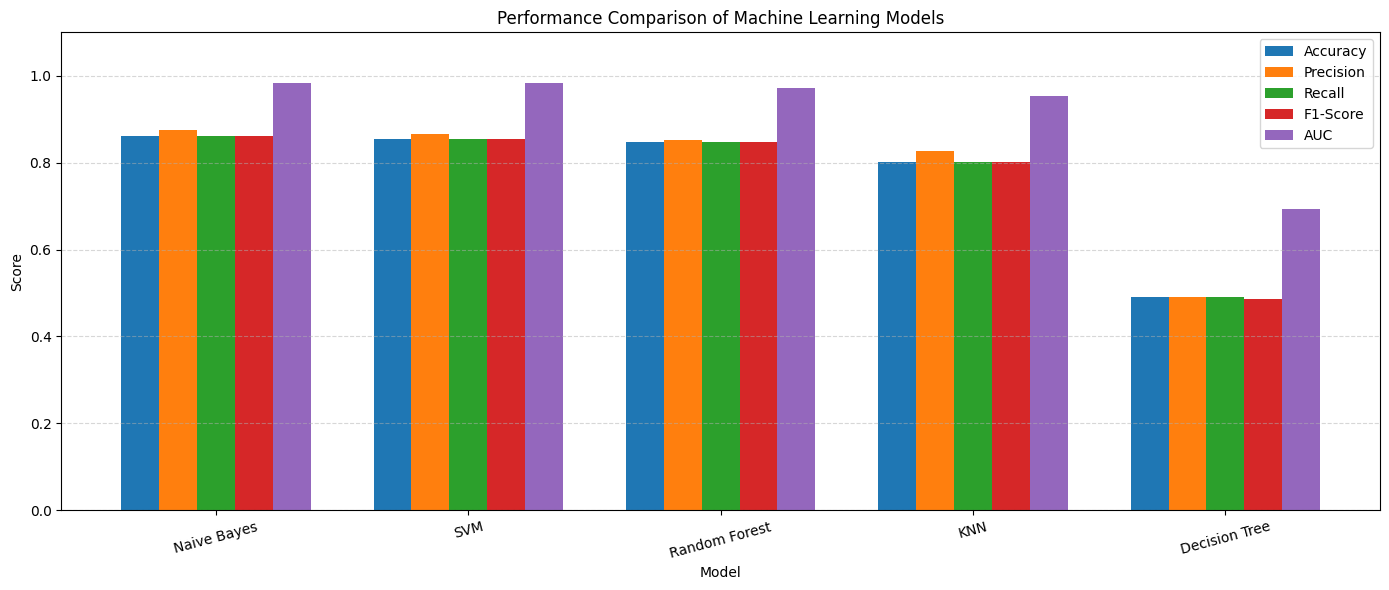

✅ Bar chart saved.


In [15]:
metrics = ["Accuracy", "Precision", "Recall", "F1-Score", "AUC"]
x = np.arange(len(results_df.index))
width = 0.15

fig, ax = plt.subplots(figsize=(14, 6))

for i, metric in enumerate(metrics):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Performance Comparison of Machine Learning Models')
ax.set_xticks(x + width * 2)
ax.set_xticklabels(results_df.index, rotation=15)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("✅ Bar chart saved.")

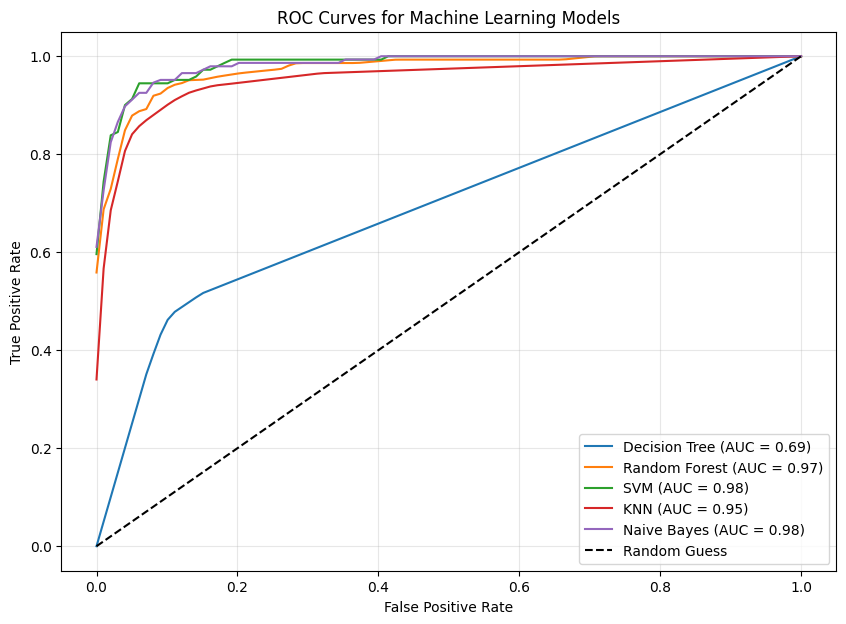

✅ ROC curves saved.


In [16]:
fig, ax = plt.subplots(figsize=(10, 7))

for name, model in trained_models.items():
    y_prob = model.predict_proba(X_test)
    # Compute macro-average ROC
    fpr_list, tpr_list = [], []
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
        fpr_list.append(fpr)
        tpr_list.append(tpr)
    # Mean FPR/TPR
    mean_fpr = np.linspace(0, 1, 100)
    mean_tpr = np.mean([np.interp(mean_fpr, fpr_list[i], tpr_list[i]) for i in range(n_classes)], axis=0)
    auc_val = results[name]["AUC"]
    ax.plot(mean_fpr, mean_tpr, label=f"{name} (AUC = {auc_val:.2f})")

ax.plot([0,1],[0,1],'k--', label='Random Guess')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves for Machine Learning Models')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.savefig('roc_curves.png', dpi=150)
plt.show()
print("✅ ROC curves saved.")

 Best Model: Naive Bayes


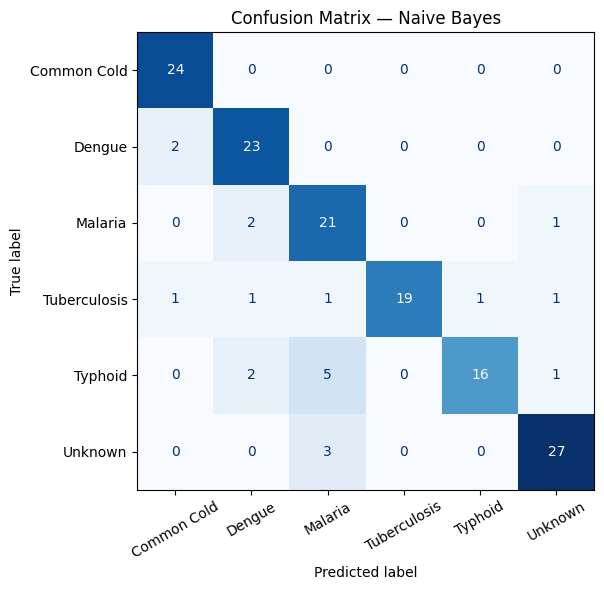


Classification Report:
              precision    recall  f1-score   support

 Common Cold       0.89      1.00      0.94        24
      Dengue       0.82      0.92      0.87        25
     Malaria       0.70      0.88      0.78        24
Tuberculosis       1.00      0.79      0.88        24
     Typhoid       0.94      0.67      0.78        24
     Unknown       0.90      0.90      0.90        30

    accuracy                           0.86       151
   macro avg       0.88      0.86      0.86       151
weighted avg       0.88      0.86      0.86       151



In [17]:
# Identify best model
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print(f" Best Model: {best_model_name}")

y_pred_best = best_model.predict(X_test)

# Fix: Use le_new instead of le because we added a 6th class
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_new.classes_)

fig, ax = plt.subplots(figsize=(8,6))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title(f'Confusion Matrix — {best_model_name}')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_best, target_names=le_new.classes_))

In [18]:
print("📐 Cross-Validation Results (5-Fold):\n")
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name, model in models.items():
    cv_scores = cross_val_score(model, X, y_encoded, cv=cv, scoring='accuracy')
    print(f"{name}: Mean={cv_scores.mean():.4f}, Std={cv_scores.std():.4f}")

📐 Cross-Validation Results (5-Fold):

Decision Tree: Mean=0.9983, Std=0.0033
Random Forest: Mean=0.9983, Std=0.0033
SVM: Mean=0.9983, Std=0.0033
KNN: Mean=0.9983, Std=0.0033
Naive Bayes: Mean=0.9983, Std=0.0033


In [19]:
# Save best model
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

# Save label encoder (needed in the web app to decode predictions)
with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)

# Save symptom column names (needed in web app for input formatting)
symptom_columns = list(X.columns)
with open('symptom_columns.pkl', 'wb') as f:
    pickle.dump(symptom_columns, f)

print(f"✅ Saved: best_model.pkl ({best_model_name})")
print("✅ Saved: label_encoder.pkl")
print("✅ Saved: symptom_columns.pkl")

✅ Saved: best_model.pkl (Naive Bayes)
✅ Saved: label_encoder.pkl
✅ Saved: symptom_columns.pkl


In [20]:
from google.colab import files

files.download('best_model.pkl')
files.download('label_encoder.pkl')
files.download('symptom_columns.pkl')
files.download('model_comparison.png')
files.download('roc_curves.png')
files.download('confusion_matrix.png')

print("✅ All files downloaded. Keep these safe — they go into your backend folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ All files downloaded. Keep these safe — they go into your backend folder.
